In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

In [2]:
freq = pd.read_csv("../data/raw/freMTPL2freq.csv")
sev = pd.read_csv("../data/raw/freMTPL2sev.csv")

Vérifier les doublons

Avant de supprimer quoi que ce soit, on mesure.

In [3]:
freq.duplicated().sum()

np.int64(0)

In [4]:
sev.duplicated().sum()

np.int64(255)

nterprétation

La vérification des doublons montre que le dataset freMTPL2freq ne contient aucun doublon. Chaque ligne représente donc un contrat unique.

En revanche, le dataset freMTPL2sev contient 255 lignes dupliquées. Avant de les supprimer, il est nécessaire de vérifier si ces doublons correspondent à de véritables répétitions ou à des enregistrements légitimes liés aux sinistres. Cette vérification est essentielle afin d'éviter de supprimer des informations utiles.

In [5]:
freq["IDpol"].duplicated().sum()

np.int64(0)

In [6]:
sev["IDpol"].duplicated().sum()

np.int64(1689)

Vérification de la clé IDpol

La colonne IDpol constitue la clé permettant de relier les deux datasets.

Dans freMTPL2freq, chaque identifiant est unique, ce qui confirme que chaque ligne représente un contrat distinct.

Dans freMTPL2sev, plusieurs lignes partagent le même IDpol. Cette situation est normale : un même contrat peut déclarer plusieurs sinistres au cours de sa période d'assurance.

Il est donc important de distinguer les doublons réels (255 lignes strictement identiques) des identifiants répétés (1 689 occurrences), qui correspondent à des sinistres différents et ne doivent pas être supprimés.

Suppression des doublons exacts

L'analyse précédente a montré que le dataset freMTPL2sev contient 255 lignes strictement identiques. Avant de les supprimer, elles sont conservées temporairement dans une variable afin de documenter l'opération de nettoyage. Cette approche permet de garder une trace des modifications apportées au dataset.

Étape 1 — Sauvegarder les doublons

In [7]:
sev_duplicates = sev[sev.duplicated()]

sev_duplicates.head()

,IDpol,ClaimAmount
162,4023587,1204.0
312,4055082,1204.0
315,4044981,1204.0
399,4041886,1204.0
409,4073123,1204.0


In [8]:
len(sev_duplicates)

255

In [9]:
sev_clean = sev.drop_duplicates()

In [10]:
print("Avant :", len(sev))
print("Après :", len(sev_clean))
print("Doublons restants :", sev_clean.duplicated().sum())

Avant : 26639
Après : 26384
Doublons restants : 0


Interprétation

Les 255 doublons exacts présents dans freMTPL2sev ont été supprimés avec succès.

Le nombre d'observations est passé de 26 639 à 26 384, sans supprimer les contrats possédant plusieurs sinistres. En effet, les répétitions de IDpol correspondant à des montants différents ont été conservées, car elles représentent des sinistres distincts.

Détection des valeurs extrêmes

Cette étape vise à identifier les valeurs extrêmes présentes dans les variables numériques et à déterminer si elles correspondent à des erreurs de saisie ou à des observations réelles. Les décisions de nettoyage seront prises à partir d'une analyse statistique et du contexte métier de l'assurance automobile.

C:\Users\user\AppData\Local\Temp\ipykernel_1332\934198548.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(freq["DrivAge"], vert=False)


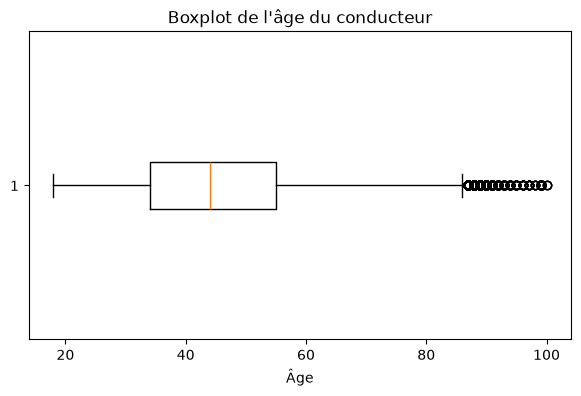

In [11]:
plt.figure(figsize=(7,4))

plt.boxplot(freq["DrivAge"], vert=False)

plt.title("Boxplot de l'âge du conducteur")
plt.xlabel("Âge")

plt.show()

Interprétation du boxplot

Le boxplot de l'âge du conducteur montre que la majorité des observations est concentrée entre environ 35 et 55 ans, avec une médiane proche de 45 ans. Plusieurs observations apparaissent au-delà de la moustache supérieure, principalement entre 86 et 100 ans. Ces observations sont considérées comme des valeurs extrêmes selon le boxplot, mais elles ne constituent pas nécessairement des erreurs de saisie. Une vérification statistique à l'aide de la méthode IQR est réalisée avant de prendre une décision de nettoyage.

In [12]:
Q1 = freq["DrivAge"].quantile(0.25)
Q3 = freq["DrivAge"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Limite inférieure :", lower)
print("Limite supérieure :", upper)

Q1 : 34.0
Q3 : 55.0
IQR : 21.0
Limite inférieure : 2.5
Limite supérieure : 86.5


In [13]:
driver_outliers = freq[freq["DrivAge"] > upper]

driver_outliers.shape

(1275, 12)

In [14]:
driver_outliers[["IDpol", "DrivAge"]].head(10)

,IDpol,DrivAge
5054,16648.0,87
5123,16781.0,95
5202,16935.0,88
5214,16956.0,87
5238,16998.0,90
5282,17082.0,90
5330,17182.0,93
5427,17366.0,90
5439,17389.0,87
5743,17961.0,90


Interprétation de la méthode IQR

La méthode IQR identifie 1 275 conducteurs âgés de 87 ans ou plus comme valeurs extrêmes.

Cependant, ces observations correspondent à des âges plausibles et ne constituent pas nécessairement des erreurs de saisie. Dans le contexte de l'assurance automobile, certains conducteurs très âgés peuvent conserver un permis de conduire et être assurés.

Par conséquent, ces observations sont conservées dans le dataset afin de préserver l'information disponible pour les analyses futures et les modèles de Machine Learning.

In [15]:
driver_outliers_percent = (
    len(driver_outliers) / len(freq)
) * 100

print(f"Pourcentage d'outliers : {driver_outliers_percent:.2f}%")

Pourcentage d'outliers : 0.19%


C:\Users\user\AppData\Local\Temp\ipykernel_1332\1408766362.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(freq["VehAge"], vert=False)


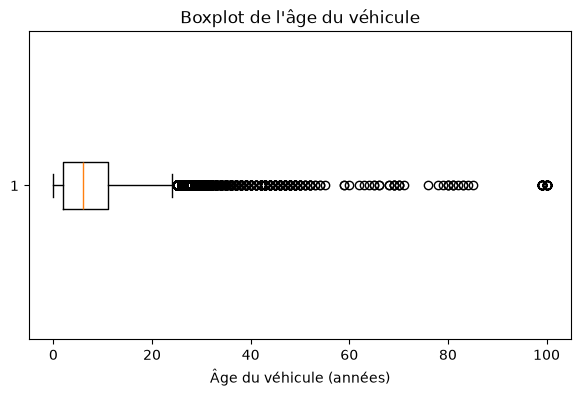

In [16]:
plt.figure(figsize=(7,4))

plt.boxplot(freq["VehAge"], vert=False)

plt.title("Boxplot de l'âge du véhicule")
plt.xlabel("Âge du véhicule (années)")

plt.show()

Interprétation du boxplot

Le boxplot montre que la majorité des véhicules ont un âge inférieur à une dizaine d'années. Plusieurs observations apparaissent au-delà de la moustache supérieure, principalement à partir de 25 ans, avec quelques valeurs très élevées allant jusqu'à 100 ans.

Ces observations sont considérées comme des valeurs extrêmes par la méthode IQR, mais une analyse complémentaire est nécessaire avant toute suppression.

In [17]:
Q1_v = freq["VehAge"].quantile(0.25)
Q3_v = freq["VehAge"].quantile(0.75)
IQR_v = Q3_v - Q1_v

lower_v = Q1_v - 1.5 * IQR_v
upper_v = Q3_v + 1.5 * IQR_v

print("Q1 :", Q1_v)
print("Q3 :", Q3_v)
print("IQR :", IQR_v)
print("Limite supérieure :", upper_v)

Q1 : 2.0
Q3 : 11.0
IQR : 9.0
Limite supérieure : 24.5


Interprétation de la méthode IQR

La méthode IQR identifie 3 114 véhicules âgés de 25 ans ou plus comme valeurs extrêmes.

Toutefois, un véhicule de 25, 30 ou même 37 ans reste plausible dans un portefeuille d'assurance. Les quelques observations atteignant 100 ans sont très rares et ne permettent pas, à elles seules, de conclure à une erreur de saisie.

Ces observations sont donc conservées afin de préserver l'information disponible pour les analyses futures et les modèles de Machine Learning.

In [18]:
vehicle_outliers = freq[freq["VehAge"] > upper_v]

vehicle_outliers.shape

(3114, 12)

In [19]:
vehicle_outliers[["IDpol", "VehAge"]].head(10)

,IDpol,VehAge
5054,16648.0,25
5058,16656.0,25
5063,16667.0,29
5160,16849.0,25
5230,16984.0,26
5274,17068.0,26
5423,17358.0,25
5530,17554.0,37
5643,17756.0,29
5816,18105.0,28


In [20]:
vehicle_outliers_percent = (
    len(vehicle_outliers) / len(freq)
) * 100

print(f"Pourcentage d'outliers : {vehicle_outliers_percent:.2f}%")

Pourcentage d'outliers : 0.46%


Les valeurs extrêmes représentent moins de 0,5 % du portefeuille et ont été conservées car elles restent plausibles dans le contexte métier.

Étape 1 — Agréger les sinistres par contrat
Markdown

Ajoute cette section.

Agrégation des montants de sinistre

Avant la fusion des deux datasets, les montants des sinistres sont regroupés par contrat (IDpol). Cette étape permet de conserver une seule ligne par contrat tout en calculant le coût total des sinistres associés.

In [21]:
sev_agg = (
    sev_clean
    .groupby("IDpol", as_index=False)
    .agg(ClaimAmountTotal=("ClaimAmount", "sum"))
)

sev_agg.head()

,IDpol,ClaimAmountTotal
0,139,303.00
1,190,1981.84
2,414,1456.55
3,424,10834.00
4,463,3986.67


In [22]:
print("Nombre de lignes :", len(sev_agg))
print("Doublons IDpol :", sev_agg["IDpol"].duplicated().sum())

Nombre de lignes : 24950
Doublons IDpol : 0


In [23]:
sev_agg.describe()

,IDpol,ClaimAmountTotal
count,2.495000e+04,2.495000e+04
mean,2.262558e+06,2.418633e+03
std,1.578285e+06,3.034494e+04
min,1.390000e+02,1.000000e+00
25%,1.082755e+06,7.497025e+02
50%,2.130128e+06,1.172000e+03
75%,3.178382e+06,1.320000e+03
max,6.113971e+06,4.075401e+06


Analyse de la sévérité des sinistres

Après agrégation des montants par contrat, le dataset sev_agg contient 24 950 contrats ayant déclaré au moins un sinistre.

Le coût moyen des sinistres est d'environ 2 418,63, tandis que la médiane est de 1 172. L'écart entre la moyenne et la médiane indique une distribution fortement asymétrique, avec quelques sinistres très coûteux qui augmentent la moyenne.

Le montant maximal dépasse 4 millions, ce qui révèle la présence de sinistres exceptionnels. Ces observations seront conservées, car elles représentent des événements rares mais réalistes dans un portefeuille d'assurance.

In [24]:
sev_agg["ClaimAmountTotal"].describe()

count    2.495000e+04
mean     2.418633e+03
std      3.034494e+04
min      1.000000e+00
25%      7.497025e+02
50%      1.172000e+03
75%      1.320000e+03
max      4.075401e+06
Name: ClaimAmountTotal, dtype: float64

In [25]:
data = freq.merge(sev_agg, on="IDpol", how="left")

In [26]:
print("Nombre de lignes :", len(data))
print("Nombre de colonnes :", data.shape[1])
print("NaN dans ClaimAmountTotal :", data["ClaimAmountTotal"].isna().sum())

Nombre de lignes : 678013
Nombre de colonnes : 13
NaN dans ClaimAmountTotal : 653069


In [27]:
data["ClaimAmountTotal"] = data["ClaimAmountTotal"].fillna(0)

In [28]:
data["ClaimAmountTotal"].isna().sum()

np.int64(0)

Interprétation de la fusion

Une fusion de type left a été réalisée entre freMTPL2freq et sev_agg en utilisant IDpol comme clé.

Cette méthode permet de conserver l'ensemble des 678 013 contrats, y compris ceux n'ayant déclaré aucun sinistre.

Les 653 069 valeurs manquantes observées dans ClaimAmountTotal correspondaient aux contrats sans sinistre. Elles ont été remplacées par 0, ce qui représente correctement un coût nul de sinistre.

In [29]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 678013 entries, 0 to 678012
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   IDpol             678013 non-null  float64
 1   ClaimNb           678013 non-null  int64  
 2   Exposure          678013 non-null  float64
 3   VehPower          678013 non-null  int64  
 4   VehAge            678013 non-null  int64  
 5   DrivAge           678013 non-null  int64  
 6   BonusMalus        678013 non-null  int64  
 7   VehBrand          678013 non-null  str    
 8   VehGas            678013 non-null  str    
 9   Area              678013 non-null  str    
 10  Density           678013 non-null  int64  
 11  Region            678013 non-null  str    
 12  ClaimAmountTotal  678013 non-null  float64
dtypes: float64(3), int64(6), str(4)
memory usage: 67.2 MB


In [30]:
data["IDpol"] = data["IDpol"].astype("int64")

In [31]:
data["IDpol"].dtype

dtype('int64')

In [32]:
print("Dimensions :", data.shape)
print("Valeurs manquantes :", data.isna().sum().sum())
print("Doublons :", data.duplicated().sum())

Dimensions : (678013, 13)
Valeurs manquantes : 0
Doublons : 0


In [33]:
from pathlib import Path

Path("../data/processed").mkdir(parents=True, exist_ok=True)

data.to_csv("../data/processed/insurance_clean.csv", index=False)

In [34]:
data["HasClaim"] = (data["ClaimNb"] > 0).astype(int)
data.to_csv("../data/processed/insurance_clean.csv", index=False)